<a href="https://colab.research.google.com/github/NielsRogge/Transformers-Tutorials/blob/master/ViTMAE/ViT_MAE_visualization_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Week 19: Autoencoders

In this notebook, we are going to visualize some predictions of a Vision Transformer (ViT) pre-trained on a very simple objective, namely masked patch prediction. The model needs to reconstruct pixel values for masked patches (as shown in the figure below).

<img src="https://user-images.githubusercontent.com/11435359/146857310-f258c86c-fde6-48e8-9cee-badd2b21bd2c.png" width="600" class="center"/>

* Paper: https://arxiv.org/abs/2111.06377
* Original repo (on which this notebook is based): https://github.com/facebookresearch/mae
* Video explaining the paper: https://www.youtube.com/watch?v=Dp6iICL2dVI 

## Set-up environment

In [1]:
!pip install -q git+https://github.com/huggingface/transformers.git


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\re72fam\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [1]:
import os

os.environ["HF_HUB_DISABLE_XET"] = "1"

## Prepare image

Here we apply some very basic image processing, namely resizing to 224x224 and normalizing the channels.

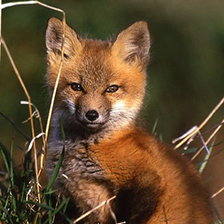

In [53]:
from transformers import ViTImageProcessor
import requests
from PIL import Image

feature_extractor = ViTImageProcessor.from_pretrained("facebook/vit-mae-base")
url = "https://user-images.githubusercontent.com/11435359/147738734-196fd92f-9260-48d5-ba7e-bf103d29364d.jpg"
image = Image.open(requests.get(url, stream=True).raw)
image

In [54]:
pixel_values = feature_extractor(image, return_tensors="pt").pixel_values

In [8]:
pixel_values.shape

torch.Size([1, 3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


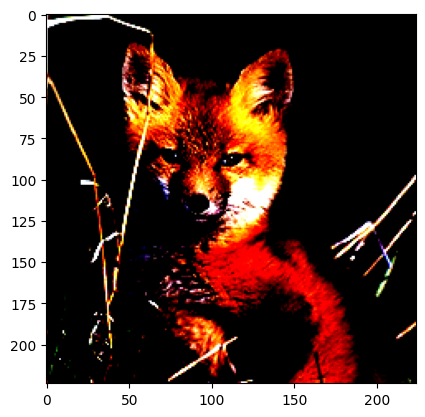

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(pixel_values[0,:,:,:].permute(1,2,0))

## Visualization

Next, we forward the pixel values through the model. The encoder (which is a standard Vision Transformer) will first encode the visual patches. Next, a learnable mask token is added at the positions of the masked patches, and the decoder (which is also a Transformer) reconstructs the pixel values based on the encoded visual patches + mask tokens.

The authors saw the best performance when masking out a large portion (75%) of the image patches.

In [55]:
import torch
import numpy as np
import matplotlib.pyplot as plt

imagenet_mean = np.array(feature_extractor.image_mean)
imagenet_std = np.array(feature_extractor.image_std)

def show_image(image, title=''):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

def visualize(pixel_values, model):
    # forward pass
    outputs = model(pixel_values)
    y = model.unpatchify(outputs.logits)
    y = torch.einsum('nchw->nhwc', y).detach().cpu()
    
    # visualize the mask
    mask = outputs.mask.detach()
    mask = mask.unsqueeze(-1).repeat(1, 1, model.config.patch_size**2 *3)  # (N, H*W, p*p*3)
    mask = model.unpatchify(mask)  # 1 is removing, 0 is keeping
    mask = torch.einsum('nchw->nhwc', mask).detach().cpu()
    
    x = torch.einsum('nchw->nhwc', pixel_values)

    # masked image
    im_masked = x * (1 - mask)

    # MAE reconstruction pasted with visible patches
    im_paste = x * (1 - mask) + y * mask

    # make the plt figure larger
    plt.rcParams['figure.figsize'] = [24, 24]

    plt.subplot(1, 4, 1)
    show_image(x[0], "original")

    plt.subplot(1, 4, 2)
    show_image(im_masked[0], "masked")

    plt.subplot(1, 4, 3)
    show_image(y[0], "reconstruction")

    plt.subplot(1, 4, 4)
    show_image(im_paste[0], "reconstruction + visible")

    plt.show()

Loading weights:   0%|          | 0/334 [00:00<?, ?it/s]

C:\Users\re72fam\AppData\Local\Temp\ipykernel_22416\3274277941.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


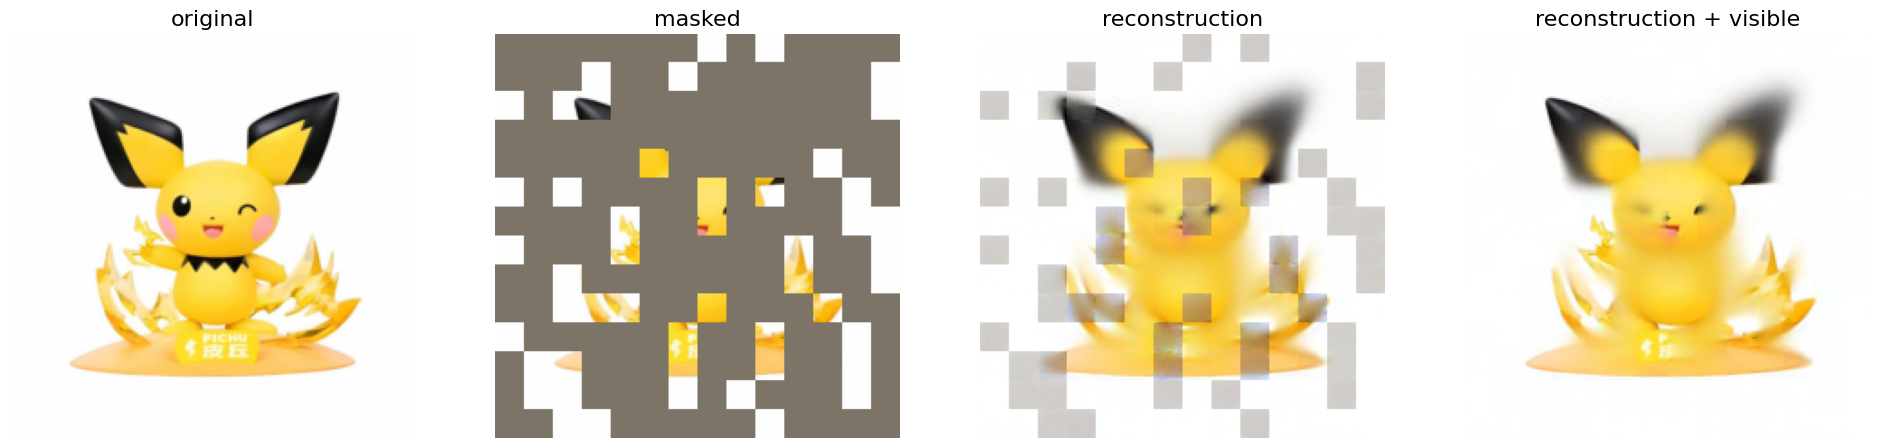

In [102]:
from transformers import ViTMAEForPreTraining

# make random mask reproducible (comment out to make it change)
torch.manual_seed(2)

model = ViTMAEForPreTraining.from_pretrained("facebook/vit-mae-base")

visualize(pixel_values, model)

In [11]:
from datasets import load_dataset

In [103]:
# Load the dataset
dataset = load_dataset("./data/pokemon_data/train")
# 2. Load the processor
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

def transform(example_batch):
    # Take a list of images and turn them into pixel values the model understands
    inputs = [x.convert('RGB') for x in example_batch['image']]
    inputs = processor(inputs, return_tensors='pt')
    #inputs['labels'] = example_batch['label']
    return inputs
# Apply the transformation to the dataset

prepared_ds = dataset.with_transform(transform)

Resolving data files:   0%|          | 0/95 [00:00<?, ?it/s]

In [33]:
prepared_ds

DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 95
    })
})

In [34]:
from transformers import TrainingArguments, Trainer, ViTMAEForPreTraining

In [104]:
model = model.to('cpu')

In [105]:
training_args = TrainingArguments(
    output_dir="./mae-ad",
    label_names=["pixel_values"],
    per_device_train_batch_size=16,
    num_train_epochs=20,
    learning_rate=1e-4,
    do_eval=False,
    remove_unused_columns=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=prepared_ds['train']
)

trainer.train()

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=120, training_loss=0.05872675180435181, metrics={'train_runtime': 127.8095, 'train_samples_per_second': 14.866, 'train_steps_per_second': 0.939, 'total_flos': 1.92036002070528e+17, 'train_loss': 0.05872675180435181, 'epoch': 20.0})

In [108]:
embedder = model.vit

In [78]:
image = Image.open("./img.jpg")
pixel_values = feature_extractor(image, return_tensors="pt").pixel_values

C:\Users\re72fam\AppData\Local\Temp\ipykernel_22416\3274277941.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


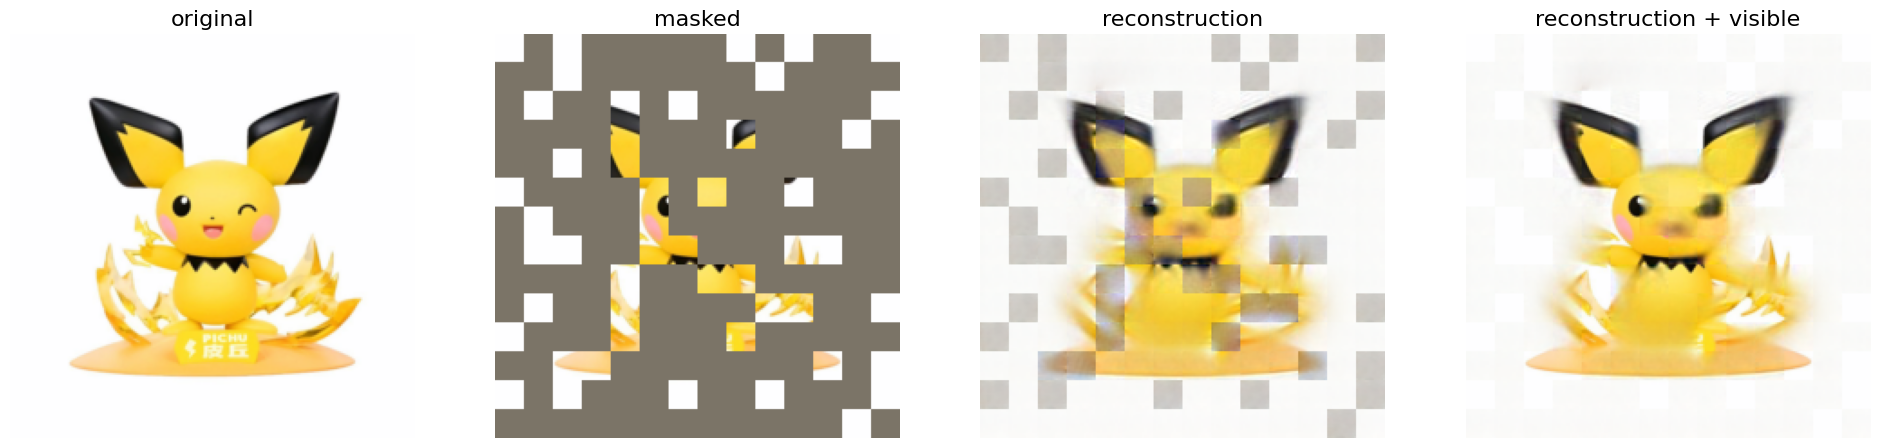

In [82]:
visualize(pixel_values, model)

In [110]:
embeddings, _, _ = embedder.to('cpu').embeddings(pixel_values)

In [111]:
embeddings.shape

torch.Size([1, 50, 768])

In [ ]:
outputs = model.to('cpu')(pixel_values)
y = model.unpatchify(outputs.logits)
y = torch.einsum('nchw->nhwc', y).detach().cpu()

In [94]:
outputs.logits.shape

torch.Size([1, 196, 768])

In [86]:
y = model.unpatchify(outputs.logits)
y

tensor([[[[2.1425, 2.1417, 2.1532,  ..., 2.1935, 2.1955, 2.1811],
          [2.1503, 2.1611, 2.1615,  ..., 2.1986, 2.1887, 2.1789],
          [2.1499, 2.1561, 2.1627,  ..., 2.1879, 2.1811, 2.1828],
          ...,
          [2.1933, 2.1978, 2.2028,  ..., 2.2069, 2.2088, 2.2055],
          [2.1978, 2.2000, 2.2053,  ..., 2.2114, 2.2094, 2.1987],
          [2.1955, 2.1974, 2.2016,  ..., 2.2059, 2.2048, 2.1998]],

         [[2.3290, 2.3255, 2.3306,  ..., 2.3673, 2.3751, 2.3670],
          [2.3356, 2.3434, 2.3369,  ..., 2.3756, 2.3710, 2.3670],
          [2.3345, 2.3387, 2.3389,  ..., 2.3657, 2.3640, 2.3706],
          ...,
          [2.3520, 2.3558, 2.3602,  ..., 2.3633, 2.3688, 2.3687],
          [2.3592, 2.3614, 2.3663,  ..., 2.3684, 2.3721, 2.3656],
          [2.3621, 2.3639, 2.3668,  ..., 2.3682, 2.3753, 2.3785]],

         [[2.5046, 2.5117, 2.5210,  ..., 2.5521, 2.5617, 2.5543],
          [2.5178, 2.5351, 2.5337,  ..., 2.5618, 2.5601, 2.5552],
          [2.5192, 2.5327, 2.5380,  ..., 2

In [91]:
torch.einsum('nchw->nhwc', y).detach().cpu()

tensor([[[[2.1425, 2.3290, 2.5046],
          [2.1417, 2.3255, 2.5117],
          [2.1532, 2.3306, 2.5210],
          ...,
          [2.1935, 2.3673, 2.5521],
          [2.1955, 2.3751, 2.5617],
          [2.1811, 2.3670, 2.5543]],

         [[2.1503, 2.3356, 2.5178],
          [2.1611, 2.3434, 2.5351],
          [2.1615, 2.3369, 2.5337],
          ...,
          [2.1986, 2.3756, 2.5618],
          [2.1887, 2.3710, 2.5601],
          [2.1789, 2.3670, 2.5552]],

         [[2.1499, 2.3345, 2.5192],
          [2.1561, 2.3387, 2.5327],
          [2.1627, 2.3389, 2.5380],
          ...,
          [2.1879, 2.3657, 2.5521],
          [2.1811, 2.3640, 2.5496],
          [2.1828, 2.3706, 2.5530]],

         ...,

         [[2.1933, 2.3520, 2.5347],
          [2.1978, 2.3558, 2.5398],
          [2.2028, 2.3602, 2.5453],
          ...,
          [2.2069, 2.3633, 2.5566],
          [2.2088, 2.3688, 2.5631],
          [2.2055, 2.3687, 2.5639]],

         [[2.1978, 2.3592, 2.5442],
          [2.2000

In [76]:
outputs

ViTMAEForPreTrainingOutput(loss=tensor(0.2283, grad_fn=<DivBackward0>), logits=tensor([[[-0.9299, -0.8731, -1.1765,  ..., -1.0491, -0.9651, -1.2841],
         [-0.9554, -0.8824, -1.1888,  ..., -1.1002, -1.0194, -1.3017],
         [-0.9835, -0.9168, -1.2068,  ..., -0.9074, -0.9555, -1.1665],
         ...,
         [ 0.4059, -0.3416, -0.8069,  ..., -0.0955, -0.4740, -0.8024],
         [-0.0579, -0.5632, -0.9132,  ..., -0.2892, -0.5664, -0.8382],
         [-0.5400, -0.7901, -0.9991,  ..., -0.3027, -0.5612, -0.8325]]],
       grad_fn=<SliceBackward0>), mask=tensor([[1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1.,
         1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0.,
         0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
         1., 1., 0., 1., 1., 1., 1.

## After pre-training

Note that, after pre-training, you can directly load the weights of the encoder into a `ViTForImageClassification` and start fine-tuning/doing linear probing. Note that a warning will be printed, indicating that the weights of the decoder aren't used.

In [6]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained("facebook/vit-mae-base")

You are using a model of type vit_mae to instantiate a model of type vit. This is not supported for all configurations of models and can yield errors.
Some weights of the model checkpoint at facebook/vit-mae-base were not used when initializing ViTForImageClassification: ['decoder.decoder_layers.0.attention.attention.value.weight', 'decoder.decoder_layers.3.output.dense.bias', 'decoder.decoder_layers.5.intermediate.dense.bias', 'decoder.decoder_layers.5.attention.attention.key.weight', 'decoder.decoder_layers.3.attention.attention.key.weight', 'decoder.decoder_layers.4.intermediate.dense.weight', 'decoder.decoder_layers.0.layernorm_before.bias', 'decoder.decoder_layers.1.layernorm_before.bias', 'decoder.decoder_layers.1.attention.attention.key.bias', 'decoder.decoder_layers.2.attention.attention.key.bias', 'decoder.decoder_layers.5.attention.attention.query.bias', 'decoder.decoder_layers.7.layernorm_after.weight', 'decoder.decoder_layers.5.attention.attention.value.weight', 'decoder.de